In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import cv2
import os
import mahotas
from itertools import product

In [ ]:
RADIUS = 50

Radius = {"calf": 62, "cat": 56, "cow": 60, "dog": 74, "donkey": 61, "fish": 60, "fox": 68, "rabbit": 52}
ImageNames = os.listdir("BaseImages")
BaseImages = {os.path.splitext(file)[0]: plt.imread(f"BaseImages/{file}")[:,:,0] for file in ImageNames}
m00_max = max(cv2.moments(img)["m00"] for img in BaseImages.values())

In [ ]:
BaseZM = {name: mahotas.features.zernike_moments(img, Radius[name]) for name, img in BaseImages.items()}

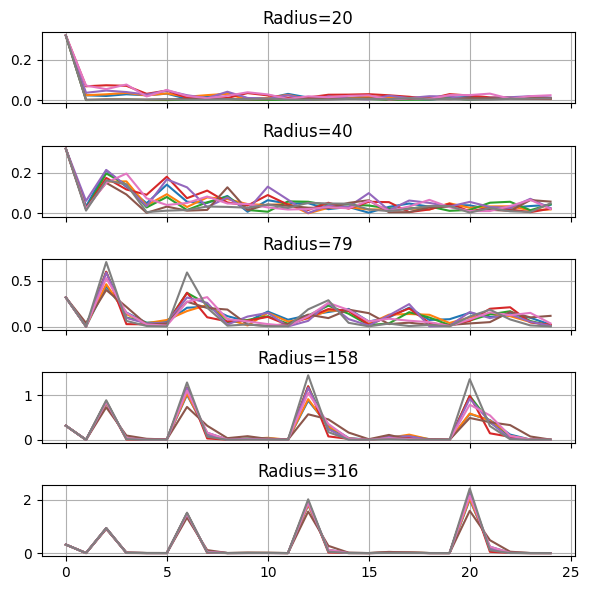

In [ ]:
radii = np.logspace(1.3, 2.5, 5)
fig, axes = plt.subplots(radii.size, 1, sharex=True, figsize=(6,6))
for a, r in zip(axes.flatten(), radii):
    ZM = {name: mahotas.features.zernike_moments(scipy.ndimage.zoom(img, m00_max/cv2.moments(img)["m00"]), r) for name, img in BaseImages.items()}
    for name, moments in ZM.items():
        a.plot(moments, label=name)
    a.set_title(f"Radius={r:.0f}")
    a.grid()
plt.tight_layout()
plt.show()

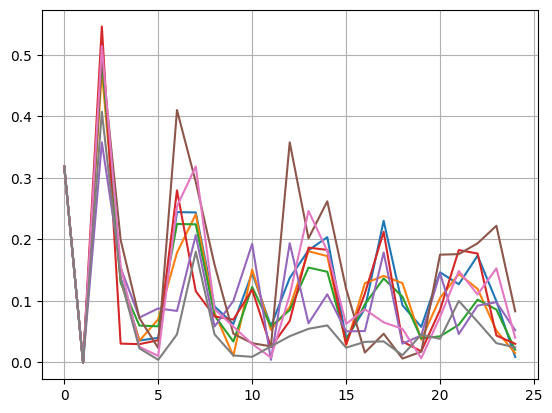

In [ ]:
for name, moments in BaseZM.items():
    plt.plot(moments, label=name)
plt.grid()
plt.show()

In [ ]:
Rot20Images = {os.path.splitext(file)[0]: (plt.imread(f"Rot20/{file}")[:,:,0] > 0.5).astype(np.uint8) for file in ImageNames}
Rot20ZM = {name: mahotas.features.zernike_moments(img, Radius[name]) for name, img in Rot20Images.items()}

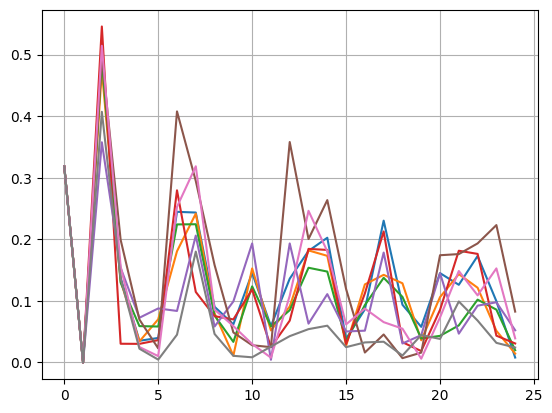

In [ ]:
for name, moments in Rot20ZM.items():
    plt.plot(moments, label=name)
plt.grid()
plt.show()

In [ ]:
ZoomOutImages = {os.path.splitext(file)[0]: (plt.imread(f"ZoomOut/{file}")[:,:,0] > 0.5).astype(np.uint8) for file in ImageNames}
ZoomOutZM = {name: mahotas.features.zernike_moments(img, Radius[name]/2) for name, img in ZoomOutImages.items()}

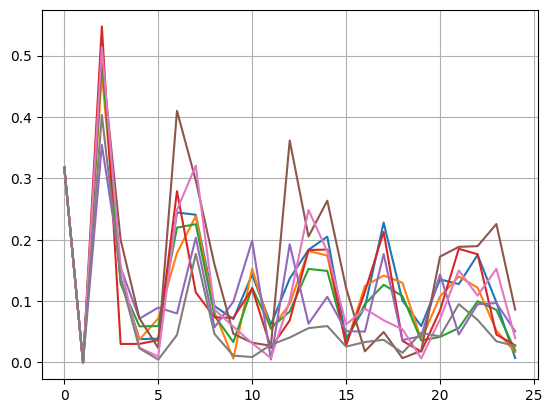

In [ ]:
for name, moments in ZoomOutZM.items():
    plt.plot(moments, label=name)
plt.grid()
plt.show()

In [ ]:
ShiftedImages = {os.path.splitext(file)[0]: (plt.imread(f"Shifted/{file}")[:,:,0] > 0.5).astype(np.uint8) for file in ImageNames}
ShiftedZM = {name: mahotas.features.zernike_moments(img, Radius[name]) for name, img in ShiftedImages.items()}

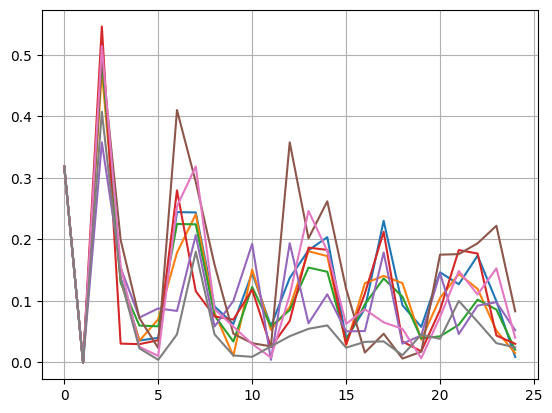

In [ ]:
for name, moments in ShiftedZM.items():
    plt.plot(moments, label=name)
plt.grid()
plt.show()

In [ ]:
Noise10dBImages = {os.path.splitext(file)[0]: (plt.imread(f"Noise10dB/{file}")[:,:,0] > 0.5).astype(np.uint8) for file in ImageNames}
Noise10dBZM = {name: mahotas.features.zernike_moments(img, Radius[name]) for name, img in Noise10dBImages.items()}

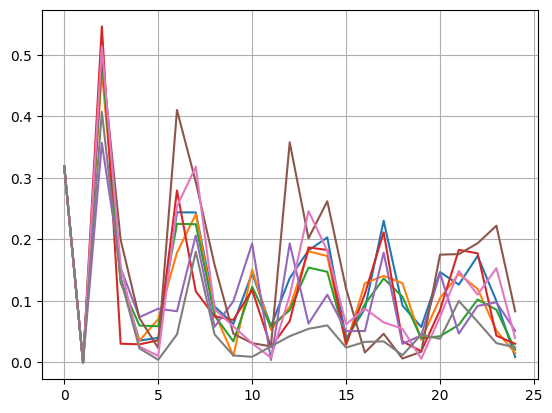

In [ ]:
for name, moments in Noise10dBZM.items():
    plt.plot(moments, label=name)
plt.grid()
plt.show()

In [ ]:
Noise5dBImages = {os.path.splitext(file)[0]: (plt.imread(f"Noise5dB/{file}")[:,:,0] > 0.5).astype(np.uint8) for file in ImageNames}
Noise5dBZM = {name: mahotas.features.zernike_moments(img, Radius[name]) for name, img in Noise5dBImages.items()}

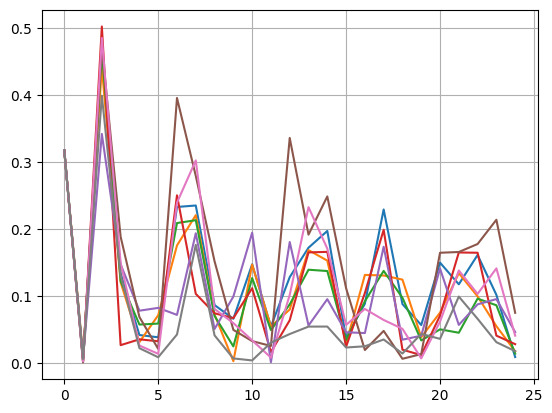

In [ ]:
for name, moments in Noise5dBZM.items():
    plt.plot(moments, label=name)
plt.grid()
plt.show()

In [ ]:
OccludeImages = {os.path.splitext(file)[0]: (plt.imread(f"Occlude/{file}")[:,:,0] > 0.5).astype(np.uint8) for file in ImageNames}
OccludeZM = {name: mahotas.features.zernike_moments(img, Radius[name]) for name, img in OccludeImages.items()}

In [ ]:
def EuclideanDistances(x_moments, y_moments):
    distances = np.zeros((len(x_moments.keys()), len(y_moments.keys())))
    for (i, n1), (j, n2) in  product(enumerate(x_moments.keys()), enumerate(y_moments.keys())):
        distances[i,j] = np.sqrt(np.sum((x_moments[n1] - y_moments[n2])**2))
    return {"dist": distances, "x_labels": list(x_moments.keys()), "y_labels": list(y_moments.keys())}

In [ ]:
def heatmap(distances, x_axis=None, y_axis=None):
    xrange = range(len(distances["x_labels"]))
    yrange = range(len(distances["y_labels"]))
    fig, ax = plt.subplots()
    im = ax.imshow(100*distances["dist"])
    ax.set_xticks(xrange, labels=distances["x_labels"])
    ax.set_yticks(yrange, labels=distances["y_labels"], rotation=90, va="center")
    for i, j in product(xrange, yrange):
        ax.text(i, j, f"{100*distances["dist"][j,i]:.1f}", ha="center", va="center", color="w")
    fig.colorbar(im)
    if x_axis is not None:
        ax.set_xlabel(x_axis)
    if y_axis is not None:
        ax.set_ylabel(y_axis)

    plt.tight_layout()
    plt.show()

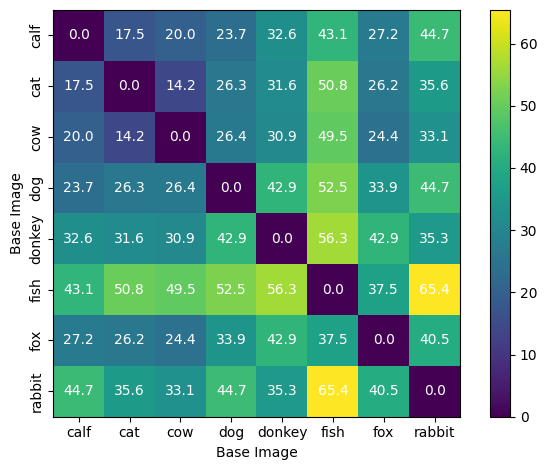

In [ ]:
heatmap(EuclideanDistances(BaseZM, BaseZM), "Base Image", "Base Image")

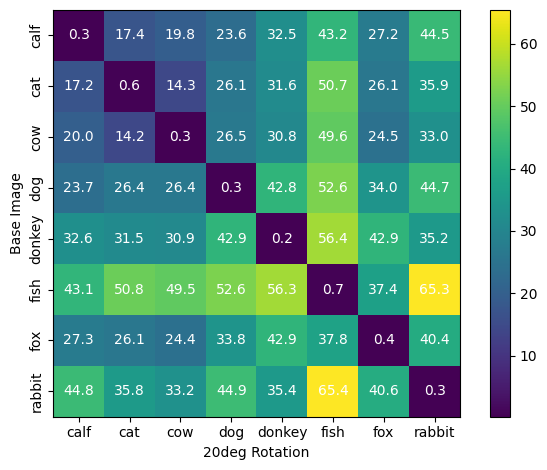

In [ ]:
heatmap(EuclideanDistances(Rot20ZM, BaseZM), "20deg Rotation", "Base Image")

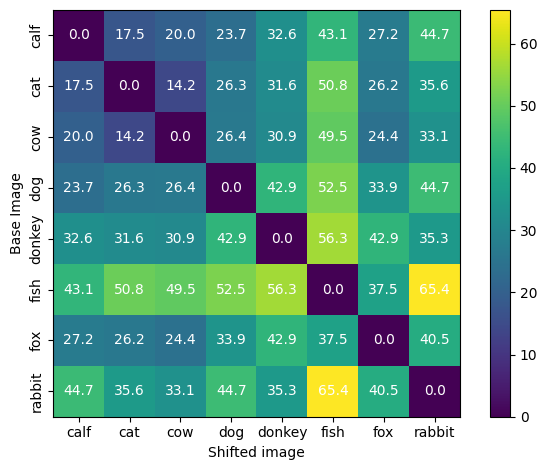

In [ ]:
heatmap(EuclideanDistances(ShiftedZM, BaseZM), "Shifted image", "Base Image")

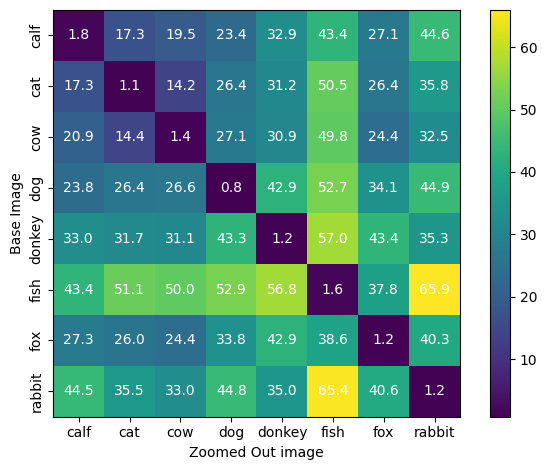

In [ ]:
heatmap(EuclideanDistances(ZoomOutZM, BaseZM), "Zoomed Out image", "Base Image")

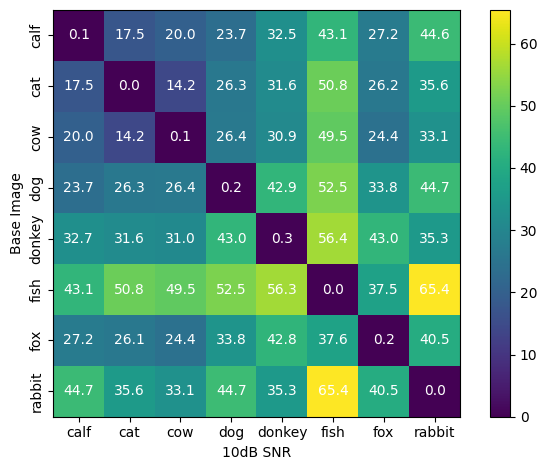

In [ ]:
heatmap(EuclideanDistances(Noise10dBZM, BaseZM), "10dB SNR", "Base Image")

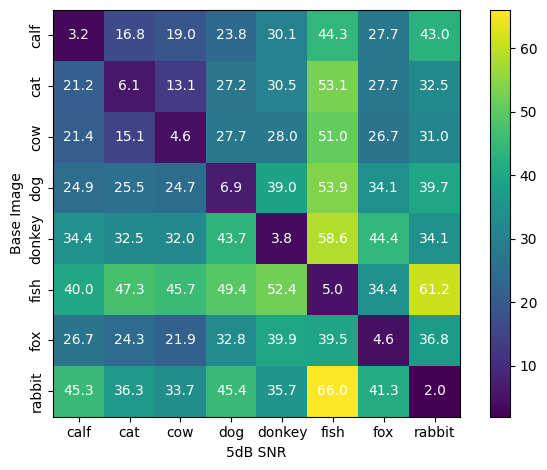

In [ ]:
heatmap(EuclideanDistances(Noise5dBZM, BaseZM), "5dB SNR", "Base Image")

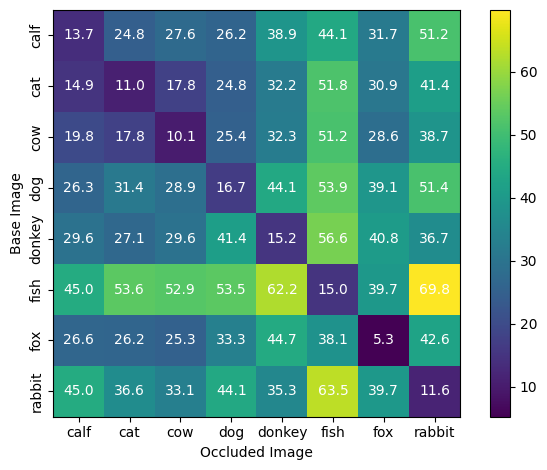

In [ ]:
heatmap(EuclideanDistances(OccludeZM, BaseZM), "Occluded Image", "Base Image")

In [ ]:
def GetComparisonRatio(base, test):
    dist = EuclideanDistances(base, test)["dist"]
    minimum = np.diag(dist).max()
    dist[np.diag_indices(dist.shape[0])] = np.inf
    return dist.min() / minimum

Ratios = np.array([GetComparisonRatio(BaseZM, t) for t in (Rot20ZM, ZoomOutZM, Noise10dBZM, Noise5dBZM, OccludeZM)])
np.save("ZMRatios", Ratios)

In [ ]:
def GetComparisonRatio2(base, test):
    dist = EuclideanDistances(base, test)["dist"]
    minimum = np.min(dist, axis=0)
    print(minimum.shape)
    dist[np.diag_indices(dist.shape[0])] = np.inf
    return dist.min() / minimum

Ratios = np.array([GetComparisonRatio2(BaseZM, t) for t in (Rot20ZM, ZoomOutZM, Noise10dBZM, Noise5dBZM, OccludeZM)])
np.save("ZMRatiosRow", Ratios)

(8,)
(8,)
(8,)
(8,)
(8,)


C:\Users\w6733\AppData\Local\Temp\ipykernel_27420\2950402096.py:6: RuntimeWarning: divide by zero encountered in divide
  return dist.min() / minimum


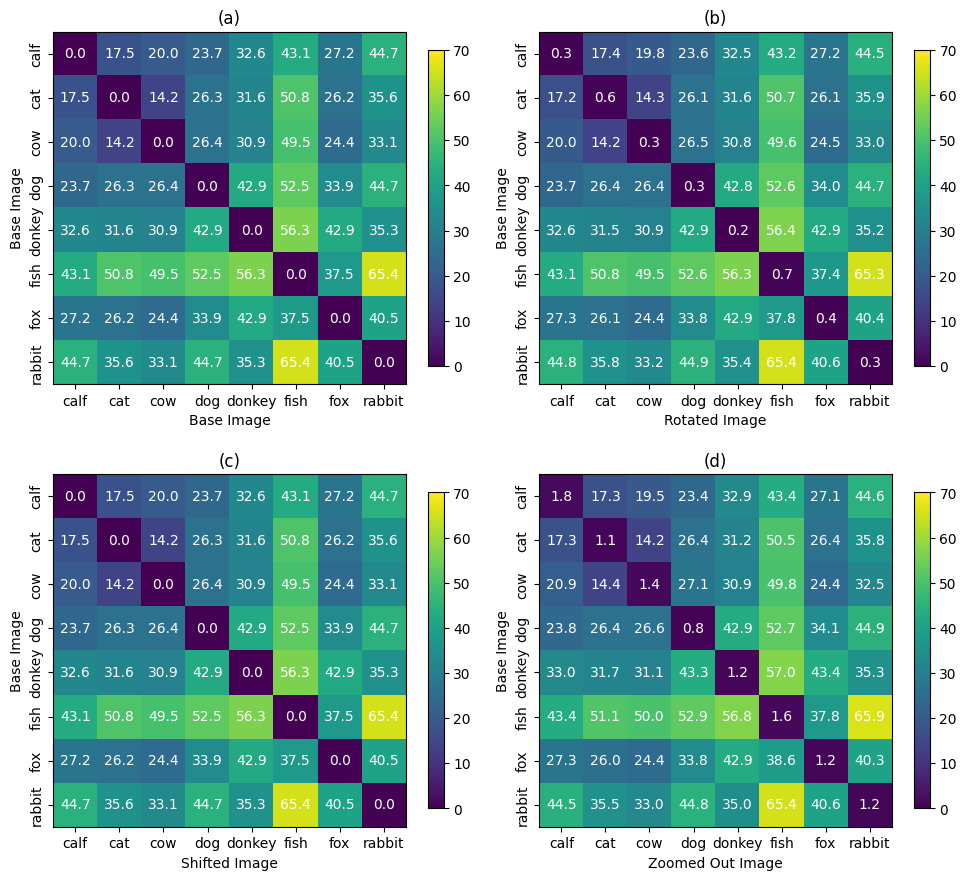

In [ ]:
BaseDist = EuclideanDistances(BaseZM, BaseZM)
Rot20Dist = EuclideanDistances(Rot20ZM, BaseZM)
ShiftedDist = EuclideanDistances(ShiftedZM, BaseZM)
ZoomOutDist = EuclideanDistances(ZoomOutZM, BaseZM)

distances = BaseDist
xrange = range(len(distances["x_labels"]))
yrange = range(len(distances["y_labels"]))
fig, axes = plt.subplots(2, 2, figsize=(10,9))
for idx, (dist, xlbl, ax) in enumerate(zip((BaseDist, Rot20Dist, ShiftedDist, ZoomOutDist), ["Base Image", "Rotated Image", "Shifted Image", "Zoomed Out Image"], axes.flatten())):
    im = ax.imshow(100*dist["dist"], vmin=0, vmax=70)
    ax.set_xticks(xrange, labels=dist["x_labels"])
    ax.set_yticks(yrange, labels=dist["y_labels"], rotation=90, va="center")
    for i, j in product(xrange, yrange):
        ax.text(i, j, f"{100*dist["dist"][j, i]:.1f}", ha="center", va="center", color="w")
    ax.set_title(f"({chr(ord("a")+idx)})")
    ax.set_ylabel("Base Image")
    ax.set_xlabel(xlbl)
    fig.colorbar(im, shrink=.8)
plt.tight_layout()
plt.show()

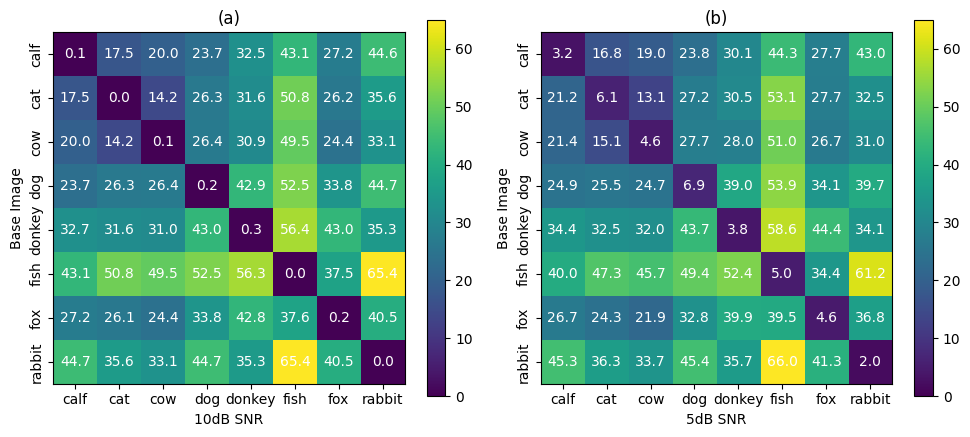

In [ ]:
Noise10dBDist = EuclideanDistances(Noise10dBZM, BaseZM)
Noise5dBDist = EuclideanDistances(Noise5dBZM, BaseZM)

distances = BaseDist
xrange = range(len(distances["x_labels"]))
yrange = range(len(distances["y_labels"]))
fig, axes = plt.subplots(1, 2, figsize=(10,5))
for idx, (dist, xlbl, ax) in enumerate(zip((Noise10dBDist, Noise5dBDist), ["10dB SNR", "5dB SNR"], axes.flatten())):
    im = ax.imshow(100*dist["dist"], vmin=0, vmax=65)
    ax.set_xticks(xrange, labels=dist["x_labels"])
    ax.set_yticks(yrange, labels=dist["y_labels"], rotation=90, va="center")
    for i, j in product(xrange, yrange):
        ax.text(i, j, f"{100*dist["dist"][j, i]:.1f}", ha="center", va="center", color="w")
    ax.set_title(f"({chr(ord("a")+idx)})")
    ax.set_ylabel("Base Image")
    ax.set_xlabel(xlbl)
    fig.colorbar(im, shrink=.8)
plt.tight_layout()
plt.show()